### 1. Libraries and basic setup

In this cell, I install and import all the Python libraries I will use in the project.  
- `kagglehub` is used to download the NBA dataset directly from Kaggle.  
- `pandas` and `numpy` are for data manipulation.  
- `scipy.stats` is for hypothesis testing.  
- `matplotlib` and `seaborn` are for visualizations.  
I also set a display option so that pandas shows more columns when printing data frames.


In [2]:
!pip install -q kagglehub scikit-learn

import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

pd.set_option("display.max_columns", 50)


### 2. Download NBA dataset from Kaggle

Here I download the NBA games dataset using `kagglehub.dataset_download`.  
The function returns a folder path where all the CSV files are stored.  
I print this path and list the files inside it to verify that the dataset has been downloaded correctly (`games.csv`, `games_details.csv`, `players.csv`, `teams.csv`, `ranking.csv`).


In [3]:
path = kagglehub.dataset_download("nathanlauga/nba-games")

print("Dataset path:", path)

import os
print("Files in that folder:", os.listdir(path))


100%|██████████| 21.2M/21.2M [00:01<00:00, 19.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/nathanlauga/nba-games/versions/10
Files in that folder: ['teams.csv', 'games.csv', 'players.csv', 'games_details.csv', 'ranking.csv']


### 3. Load CSV files into pandas DataFrames

In this cell I read the main CSV files into pandas DataFrames:
- `games` contains game-level statistics and final results.
- `games_details` contains player-level box score statistics for each game.
- `players`, `teams`, and `ranking` are additional metadata tables (not heavily used yet).
At the end I print the shapes of `games` and `games_details` to confirm that the data loaded successfully.


In [4]:
games = pd.read_csv(os.path.join(path, "games.csv"))
games_details = pd.read_csv(os.path.join(path, "games_details.csv"))
players = pd.read_csv(os.path.join(path, "players.csv"))
teams = pd.read_csv(os.path.join(path, "teams.csv"))
ranking = pd.read_csv(os.path.join(path, "ranking.csv"))

games.shape, games_details.shape


/tmp/ipython-input-4047788856.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  games_details = pd.read_csv(os.path.join(path, "games_details.csv"))


((26651, 21), (668628, 29))

### 4. Basic data cleaning and preprocessing

This cell performs initial cleaning steps:

1. Convert the game date column `GAME_DATE_EST` to a proper datetime type.  
2. (Optional) Filter to seasons from 2010 onward to focus on more recent years.  
3. Convert the minutes played in `games_details` from a `"MM:SS"` string to a numeric value in minutes (`MIN_float`).  
4. Keep only rows where the player actually played more than 0 minutes.

After these steps, both `games` and `games_details` are cleaner and ready for analysis.


In [5]:
games.head()
games_details.head()
games['GAME_DATE_EST'] = pd.to_datetime(games['GAME_DATE_EST'])

games = games[games['SEASON'] >= 2010].copy()

def parse_minutes(min_str):
    if pd.isna(min_str):
        return np.nan
    try:
        m, s = str(min_str).split(':')
        return int(m) + int(s) / 60.0
    except ValueError:
        return np.nan

games_details['MIN_float'] = games_details['MIN'].apply(parse_minutes)

games_details = games_details[games_details['MIN_float'] > 0].copy()

games.shape, games_details.shape


((16793, 21), (534698, 30))

### 5. Define star players and subset their game data

Here I define a list of well-known star players (LeBron James, Stephen Curry, Kevin Durant, James Harden, Nikola Jokic).  
Using this list, I filter `games_details` to keep only the rows where one of these players appears.  
The result `star_details` contains the box score statistics for the selected star players in each game.


In [6]:
star_players = [
    "LeBron James",
    "Stephen Curry",
    "Kevin Durant",
    "James Harden",
    "Nikola Jokic"
]

star_details = games_details[games_details['PLAYER_NAME'].isin(star_players)].copy()
star_details[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'GAME_ID', 'PTS', 'AST', 'REB']].head()


,PLAYER_NAME,TEAM_ABBREVIATION,GAME_ID,PTS,AST,REB
94,James Harden,PHI,22200467,15.0,8.0,2.0
164,Kevin Durant,BKN,22200470,23.0,5.0,7.0
276,LeBron James,LAL,22200475,31.0,11.0,6.0
488,James Harden,PHI,22200453,14.0,8.0,7.0
722,Kevin Durant,BKN,22200447,43.0,2.0,6.0


### 6. Build star-game dataset with team results and impact features

In this cell I link each star player’s performance to the corresponding game outcome:

1. From `games`, I keep only the relevant game-level columns (scores, rebounds, assists, and win flag).  
2. I merge `star_details` with this game information using `GAME_ID`.  
3. I determine whether the star’s team is the home team (`is_home`).  
4. From the home/away statistics, I compute the star’s team points, assists, and rebounds from the correct side.  
5. I calculate the point differential from the star team’s perspective.  
6. I create `star_team_win`, which is 1 if the star’s team won and 0 otherwise.  
7. I compute `pts_share`, the fraction of the team’s total points scored by the star.

The resulting `star_games` DataFrame is the main dataset for the analysis of star player impact.


In [7]:
games_small = games[[
    'GAME_ID', 'GAME_DATE_EST', 'SEASON',
    'HOME_TEAM_ID', 'VISITOR_TEAM_ID',
    'PTS_home', 'PTS_away',
    'AST_home', 'AST_away',
    'REB_home', 'REB_away',
    'HOME_TEAM_WINS'
]].copy()

star_games = pd.merge(
    star_details,
    games_small,
    on='GAME_ID',
    how='inner',
    suffixes=('', '_game')
)

star_games['is_home'] = star_games['TEAM_ID'] == star_games['HOME_TEAM_ID']

star_games['team_pts'] = np.where(star_games['is_home'], star_games['PTS_home'], star_games['PTS_away'])
star_games['team_ast'] = np.where(star_games['is_home'], star_games['AST_home'], star_games['AST_away'])
star_games['team_reb'] = np.where(star_games['is_home'], star_games['REB_home'], star_games['REB_away'])

star_games['point_diff'] = np.where(
    star_games['is_home'],
    star_games['PTS_home'] - star_games['PTS_away'],
    star_games['PTS_away'] - star_games['PTS_home']
)

star_games['star_team_win'] = np.where(
    star_games['is_home'],
    star_games['HOME_TEAM_WINS'],
    1 - star_games['HOME_TEAM_WINS']
)

star_games['pts_share'] = star_games['PTS'] / star_games['team_pts']

star_games[['PLAYER_NAME', 'GAME_DATE_EST', 'PTS', 'team_pts', 'pts_share', 'star_team_win']].head()


,PLAYER_NAME,GAME_DATE_EST,PTS,team_pts,pts_share,star_team_win
0,James Harden,2022-12-21,15.0,113.0,0.132743,1
1,Kevin Durant,2022-12-21,23.0,143.0,0.160839,1
2,LeBron James,2022-12-21,31.0,120.0,0.258333,0
3,James Harden,2022-12-19,14.0,104.0,0.134615,1
4,Kevin Durant,2022-12-18,43.0,124.0,0.346774,1


### 7. Descriptive statistics for star performance

This cell performs basic exploratory data analysis on the `star_games` dataset:

- I use `.describe()` to get summary statistics (mean, standard deviation, quartiles, etc.) for key variables such as points, assists, rebounds, points share, and point differential.  
- I also group by `PLAYER_NAME` to see average performance and variability for each individual star.

These summaries give a first overview of how the star players typically perform and how large their contribution is to team scoring.


In [8]:
# Summary of star performance & impact
star_games[['PTS', 'AST', 'REB', 'pts_share', 'point_diff']].describe().T
star_games.groupby('PLAYER_NAME')[['PTS', 'AST', 'REB', 'pts_share']].agg(['mean', 'std', 'median', 'count'])


PTS                               AST                   \
                    mean        std median count      mean       std median   
PLAYER_NAME                                                                   
James Harden   25.603561  10.703023   25.0  1067  7.148079  3.710515    7.0   
Kevin Durant   27.910773   7.699608   28.0   919  4.709467  2.514756    4.0   
LeBron James   26.682287   7.491665   26.0  1067  7.428304  3.084377    7.0   
Nikola Jokic   19.985981   9.593523   20.0   642  6.241433  3.520295    6.0   
Stephen Curry  25.225705   9.637642   25.0   957  6.439916  2.800141    6.0   

                           REB                        pts_share            \
              count       mean       std median count      mean       std   
PLAYER_NAME                                                                 
James Harden   1067   5.761949  2.971019    6.0  1067  0.233037  0.091350   
Kevin Durant    919   7.340588  3.202735    7.0   919  0.255120  0.072038   
LeBron James   1067   7.942830  3.153888    8.0  1067  0.252284  0.070406   
Nikola Jokic    642  10.252336  4.243950   10.0   642  0.180147  0.083048   
Stephen Curry   957   4.753396  2.450728    5.0   957  0.226110  0.080435   

                               
                 median count  
PLAYER_NAME                    
James Harden   0.230088  1067  
Kevin Durant   0.254098   919  
LeBron James   0.247788  1067  
Nikola Jokic   0.178717   642  
Stephen Curry  0.224719   957

### 8. Visual exploratory data analysis

In this cell I create visualizations to better understand the data:

1. A histogram of star players’ points per game to see the overall scoring distribution.  
2. Boxplots comparing star points in games their team loses vs. games their team wins.  
3. A similar boxplot for `pts_share` (how much of the team’s scoring the star provides) in wins vs. losses.  
4. A correlation heatmap showing the relationships between star performance statistics (points, assists, rebounds, points share) and team point differential.

These plots help reveal patterns, such as whether higher scoring or higher point share tends to be associated with larger margins of victory.


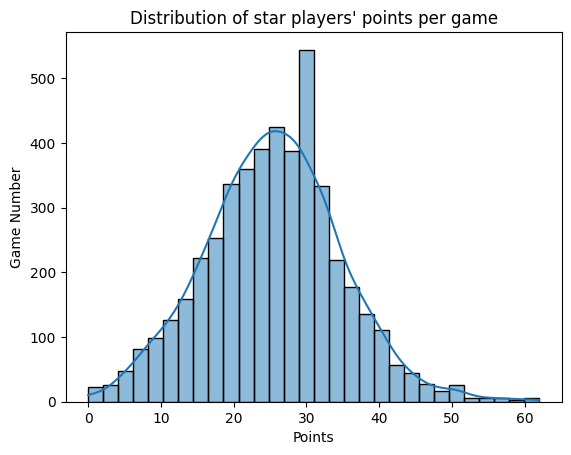

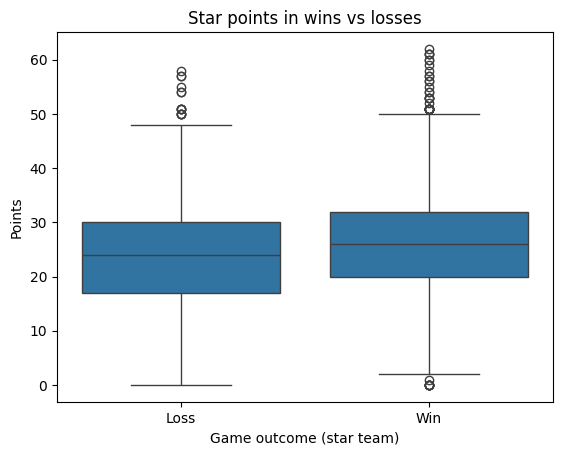

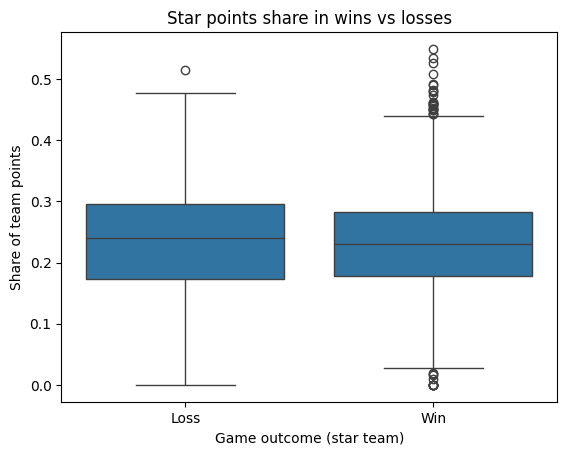

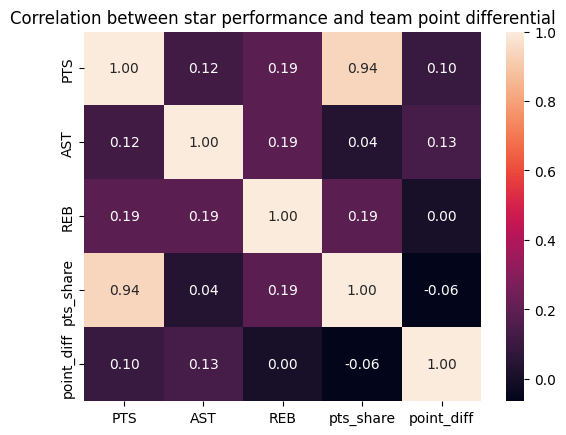

In [9]:
plt.figure()
sns.histplot(star_games['PTS'], bins=30, kde=True)
plt.title("Distribution of star players' points per game")
plt.xlabel("Points")
plt.ylabel("Game Number")
plt.show()

plt.figure()
sns.boxplot(x='star_team_win', y='PTS', data=star_games)
plt.xticks([0, 1], ['Loss', 'Win'])
plt.title("Star points in wins vs losses")
plt.xlabel("Game outcome (star team)")
plt.ylabel("Points")
plt.show()

plt.figure()
sns.boxplot(x='star_team_win', y='pts_share', data=star_games)
plt.xticks([0, 1], ['Loss', 'Win'])
plt.title("Star points share in wins vs losses")
plt.xlabel("Game outcome (star team)")
plt.ylabel("Share of team points")
plt.show()


corr_cols = ['PTS', 'AST', 'REB', 'pts_share', 'point_diff']
corr_matrix = star_games[corr_cols].corr()

plt.figure()
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation between star performance and team point differential")
plt.show()


### 9. Define high-scoring games relative to each star

Here I create a new Boolean variable `high_pts`:

- For each player separately, I compute their median points per game.  
- A game is labeled `high_pts = True` if the star’s points in that game are above that player’s own median; otherwise it is `False`.

This creates a simple way to classify games into “high scoring” vs. “normal/low scoring” relative to each star’s usual performance, which is needed for the first hypothesis test.


In [10]:
star_games['high_pts'] = star_games.groupby('PLAYER_NAME')['PTS'] \
                                   .transform(lambda x: x > x.median())

star_games[['PLAYER_NAME', 'PTS', 'high_pts']].head()


,PLAYER_NAME,PTS,high_pts
0,James Harden,15.0,False
1,Kevin Durant,23.0,False
2,LeBron James,31.0,True
3,James Harden,14.0,False
4,Kevin Durant,43.0,True


### 10. Hypothesis Test 1 – Win rate when the star scores high vs low

In this cell I test whether teams win more often when their star has a high-scoring game.

Steps:

1. Split the data into two groups: games with `high_pts = True` and games with `high_pts = False`.
2. Compute the win rate (`star_team_win` mean) in each group.
3. Perform a two-proportion z-test:
   - Null hypothesis \(H_0\): the win probability is the same in both groups \(p_{high} = p_{low}\).
   - Alternative hypothesis \(H_1\): the win probability is higher when the star scores above their median \(p_high} > p_{low}\).
4. Calculate the z-statistic and one-sided p-value.

**Numerical results**

- Win rate when the star scores **high**: ≈ **0.691** (69.1%)  
- Win rate when the star scores **low**: ≈ **0.622** (62.2%)  
- Difference in win rate: ≈ **6.9 percentage points**  
- z-statistic: ≈ **4.89**  
- One-sided p-value: ≈ **4.96 × 10⁻⁷**

Because the p-value is far below 0.05, I reject \(H_0\) and conclude that teams win **significantly more often** when their star scores above their usual (median) point level.


In [11]:
high_group = star_games[star_games['high_pts']]
low_group  = star_games[~star_games['high_pts']]

wins_high = high_group['star_team_win'].sum()
n_high    = high_group.shape[0]

wins_low  = low_group['star_team_win'].sum()
n_low     = low_group.shape[0]

p_high = wins_high / n_high
p_low  = wins_low / n_low

print("Win rate when star scores high:", p_high)
print("Win rate when star scores low :", p_low)

p_pool = (wins_high + wins_low) / (n_high + n_low)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_high + 1/n_low))
z_stat = (p_high - p_low) / se

p_value = 1 - stats.norm.cdf(z_stat)

z_stat, p_value


Win rate when star scores high: 0.690712353471596
Win rate when star scores low : 0.6224322103533279


(np.float64(4.893071795309229), np.float64(4.963708525318467e-07))

### 11. Hypothesis Test 2 – Do stars score more in wins than in losses?

This cell tests whether star players score more points in games their team wins than in games their team loses.

Steps:

1. Split star games into two groups based on `star_team_win` (wins vs losses).
2. Compute the average points in each group.
3. Apply a Welch two-sample t-test:
   - Null hypothesis \(H_0\): mean points in wins = mean points in losses.
   - Alternative hypothesis \(H_1\): mean points are higher in wins.
4. Convert the two-sided p-value to a one-sided p-value for the directional hypothesis.

**Numerical results**

- Mean points in **wins**: ≈ **26.28**  
- Mean points in **losses**: ≈ **23.89**  
- Difference in means: ≈ **2.39 points**  
- t-statistic: ≈ **8.25**  
- One-sided p-value: ≈ **1.21 × 10⁻¹⁶**

The p-value is extremely small, so I reject \(H_0\) and conclude that star players score **significantly more points** in games their team wins than in games their team loses. On average, they score about 2–2.5 extra points in wins.


In [12]:
pts_win  = star_games.loc[star_games['star_team_win'] == 1, 'PTS']
pts_loss = star_games.loc[star_games['star_team_win'] == 0, 'PTS']

print("Mean PTS (wins) :", pts_win.mean())
print("Mean PTS (losses):", pts_loss.mean())

t_stat, p_val_two_sided = stats.ttest_ind(pts_win, pts_loss, equal_var=False, nan_policy='omit')

p_val_one_sided = p_val_two_sided / 2 if t_stat > 0 else 1 - p_val_two_sided / 2
t_stat, p_val_one_sided


Mean PTS (wins) : 26.27765014768625
Mean PTS (losses): 23.889719626168223


(np.float64(8.243533937572613), np.float64(1.2056835556364593e-16))

### 12. Prepare star_games for ML (sorting + target)

In this cell, I prepare the star_games dataset for modeling.

I ensure GAME_DATE_EST is a datetime and sort by date so that later splits can respect time order.

I define the ML target variable y = star_team_win (win/loss from the star’s team perspective).

I convert is_home to an integer (0/1) so it can be used as a numeric feature.

I print the number of rows and the overall win rate to sanity-check the dataset.

In [13]:
star_games = star_games.copy()
star_games["GAME_DATE_EST"] = pd.to_datetime(star_games["GAME_DATE_EST"])
star_games = star_games.sort_values("GAME_DATE_EST")

y = star_games["star_team_win"].astype(int)

if star_games["is_home"].dtype == bool:
    star_games["is_home"] = star_games["is_home"].astype(int)

print("Rows:", len(star_games))
print("Win rate overall:", y.mean())
print(star_games[["PLAYER_NAME", "SEASON", "GAME_DATE_EST", "star_team_win", "is_home"]].head())


Rows: 4652
Win rate overall: 0.6549871023215821
        PLAYER_NAME  SEASON GAME_DATE_EST  star_team_win  is_home
1702   LeBron James    2010    2010-10-26              0        0
1701   LeBron James    2010    2010-10-27              1        0
1700   James Harden    2010    2010-10-27              1        1
1699   Kevin Durant    2010    2010-10-27              1        1
1698  Stephen Curry    2010    2010-10-27              1        1


### 13. Define feature sets

In this cell, I define the input features for multiple modeling setups so I can compare “star-only” vs “star + context” vs “star + team totals”.

I first define a candidate list of star box-score features and keep only the columns that actually exist in the DataFrame.

S (Star-only): uses only star performance statistics (points, assists, rebounds, shooting, etc.).

SC (Star + Context): adds contextual features such as is_home and SEASON.

ST (Star + Team totals): adds team-level totals like team_pts, team_ast, team_reb, and pts_share.

I print feature counts so I can confirm each feature set is built correctly.

In [14]:
def existing_cols(df, cols):
    return [c for c in cols if c in df.columns]

star_only_candidates = [
    "PTS", "AST", "REB",
    "MIN_float",
    "FG_PCT", "FG3_PCT", "FT_PCT",
    "FGM", "FGA", "FG3M", "FG3A", "FTM", "FTA",
    "STL", "BLK", "TO", "PF",
    "PLUS_MINUS"
]

X_cols_S = existing_cols(star_games, star_only_candidates)

context_candidates = ["is_home", "SEASON"]
X_cols_SC = sorted(set(X_cols_S + existing_cols(star_games, context_candidates)))

team_total_candidates = ["team_pts", "team_ast", "team_reb", "pts_share"]
X_cols_ST = sorted(set(X_cols_SC + existing_cols(star_games, team_total_candidates)))

print("Feature counts:")
print("S :", len(X_cols_S), X_cols_S)
print("SC:", len(X_cols_SC))
print("ST:", len(X_cols_ST))


Feature counts:
S : 18 ['PTS', 'AST', 'REB', 'MIN_float', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'STL', 'BLK', 'TO', 'PF', 'PLUS_MINUS']
SC: 20
ST: 24


### 14. Train/Validation/Test split by season

In this cell, I define a time-aware split so evaluation is more realistic.

I create boolean masks for train, validation, and test using seasons (train ≤ 2019, val 2020–2021, test ≥ 2022).

I implement split_Xy(cols) which returns (X_train, y_train, X_val, y_val, X_test, y_test) for any chosen feature list.

I print split sizes to confirm there is enough data in each subset.

In [15]:
train_mask = star_games["SEASON"] <= 2019
val_mask   = (star_games["SEASON"] >= 2020) & (star_games["SEASON"] <= 2021)
test_mask  = star_games["SEASON"] >= 2022

def split_Xy(cols):
    X = star_games[cols].copy()
    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val     = X[val_mask], y[val_mask]
    X_test, y_test   = X[test_mask], y[test_mask]
    return X_train, y_train, X_val, y_val, X_test, y_test

print("Train size:", train_mask.sum())
print("Val size  :", val_mask.sum())
print("Test size :", test_mask.sum())


Train size: 3809
Val size  : 706
Test size : 137


### 15. Preprocessing pipeline

In this cell, I create a reusable preprocessing function for numeric features.

Missing values are filled using the median.

Features are standardized using StandardScaler.

The function returns a ColumnTransformer so it can be plugged into scikit-learn pipelines cleanly.

In [31]:
def make_preprocessor(X_cols):
    numeric_features = X_cols

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features)
        ],
        remainder="drop"
    )
    return preprocessor


### 16. Unified evaluation function for classification models

In this cell, I define evaluate_classifier(...) to evaluate any model consistently.

The model is fitted on the training data once.

I compute metrics on train, validation, and test splits: accuracy, balanced accuracy, precision, recall, F1, ROC-AUC, and confusion matrix.

If the model supports predict_proba, I compute ROC-AUC; otherwise it returns NaN.

The function returns a small DataFrame with one row per split, enabling easy comparison across models.

In [32]:
def evaluate_classifier(name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)

    def metrics_for_split(Xs, ys, split_name):
        y_pred = model.predict(Xs)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(Xs)[:, 1]
            auc = roc_auc_score(ys, y_prob)
        else:
            auc = np.nan

        return {
            "model": name,
            "split": split_name,
            "accuracy": accuracy_score(ys, y_pred),
            "balanced_acc": balanced_accuracy_score(ys, y_pred),
            "precision": precision_score(ys, y_pred, zero_division=0),
            "recall": recall_score(ys, y_pred, zero_division=0),
            "f1": f1_score(ys, y_pred, zero_division=0),
            "roc_auc": auc,
            "confusion_matrix": confusion_matrix(ys, y_pred)
        }

    rows = []
    rows.append(metrics_for_split(X_train, y_train, "train"))
    rows.append(metrics_for_split(X_val, y_val, "val"))
    rows.append(metrics_for_split(X_test, y_test, "test"))

    return pd.DataFrame(rows)


### 17. Dummy baseline

In this cell, I run a DummyClassifier baseline.

The dummy model predicts the most frequent class (usually “win”) every time.

This is a baseline to show that real ML models are improving performance beyond a trivial strategy.

In [18]:
results = []

for feat_name, cols in [("S", X_cols_S), ("SC", X_cols_SC), ("ST", X_cols_ST)]:
    X_train, y_train, X_val, y_val, X_test, y_test = split_Xy(cols)

    dummy = DummyClassifier(strategy="most_frequent")
    res = evaluate_classifier(f"Dummy({feat_name})", dummy, X_train, y_train, X_val, y_val, X_test, y_test)
    results.append(res)

all_results = pd.concat(results, ignore_index=True)
all_results[["model","split","accuracy","balanced_acc","precision","recall","f1","roc_auc"]]


,model,split,accuracy,balanced_acc,precision,recall,f1,roc_auc
0,Dummy(S),train,0.666054,0.5,0.666054,1.0,0.799559,0.5
1,Dummy(S),val,0.613314,0.5,0.613314,1.0,0.760316,0.5
2,Dummy(S),test,0.562044,0.5,0.562044,1.0,0.719626,0.5
3,Dummy(SC),train,0.666054,0.5,0.666054,1.0,0.799559,0.5
4,Dummy(SC),val,0.613314,0.5,0.613314,1.0,0.760316,0.5
5,Dummy(SC),test,0.562044,0.5,0.562044,1.0,0.719626,0.5
6,Dummy(ST),train,0.666054,0.5,0.666054,1.0,0.799559,0.5
7,Dummy(ST),val,0.613314,0.5,0.613314,1.0,0.760316,0.5
8,Dummy(ST),test,0.562044,0.5,0.562044,1.0,0.719626,0.5


### 18. Logistic Regression models

In this cell, I train and evaluate Logistic Regression using pipelines.

Each model includes preprocessing (impute + scale) followed by Logistic Regression.

I run the same model across S, SC, and ST feature sets.

In [19]:
results = []

for feat_name, cols in [("S", X_cols_S), ("SC", X_cols_SC), ("ST", X_cols_ST)]:
    X_train, y_train, X_val, y_val, X_test, y_test = split_Xy(cols)

    preprocessor = make_preprocessor(cols)

    clf = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000, solver="lbfgs"))
    ])

    res = evaluate_classifier(f"LogReg({feat_name})", clf, X_train, y_train, X_val, y_val, X_test, y_test)
    results.append(res)

logreg_results = pd.concat(results, ignore_index=True)
logreg_results[["model","split","accuracy","balanced_acc","precision","recall","f1","roc_auc"]]


,model,split,accuracy,balanced_acc,precision,recall,f1,roc_auc
0,LogReg(S),train,0.855080,0.826139,0.874670,0.913283,0.893560,0.925058
1,LogReg(S),val,0.832861,0.812307,0.837259,0.903002,0.868889,0.916115
2,LogReg(S),test,0.781022,0.764719,0.758242,0.896104,0.821429,0.912771
3,LogReg(SC),train,0.855605,0.827709,0.876468,0.911707,0.893740,0.926372
4,LogReg(SC),val,0.835694,0.815293,0.839400,0.905312,0.871111,0.916512
5,LogReg(SC),test,0.788321,0.774892,0.772727,0.883117,0.824242,0.908658
6,LogReg(ST),train,0.872145,0.849533,0.893323,0.917619,0.905308,0.938767
7,LogReg(ST),val,0.869688,0.858573,0.883146,0.907621,0.895216,0.937873
8,LogReg(ST),test,0.824818,0.816558,0.819277,0.883117,0.850000,0.928788


### 19. Decision Tree models

In this cell, I train and evaluate a Decision Tree classifier.

Trees do not require scaling, but they do require missing-value handling, so I apply median imputation only.

I use constraints like max_depth and min_samples_leaf to reduce overfitting.

I evaluate the tree across S, SC, and ST feature sets to compare it against Logistic Regression.

In [33]:
results = []

for feat_name, cols in [("S", X_cols_S), ("SC", X_cols_SC), ("ST", X_cols_ST)]:
    X_train, y_train, X_val, y_val, X_test, y_test = split_Xy(cols)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), cols)
        ],
        remainder="drop"
    )

    tree = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=20,
            random_state=42
        ))
    ])

    res = evaluate_classifier(f"Tree({feat_name})", tree, X_train, y_train, X_val, y_val, X_test, y_test)
    results.append(res)

tree_results = pd.concat(results, ignore_index=True)
tree_results[["model","split","accuracy","balanced_acc","precision","recall","f1","roc_auc"]]


,model,split,accuracy,balanced_acc,precision,recall,f1,roc_auc
0,Tree(S),train,0.871357,0.857566,0.906958,0.899093,0.903009,0.934019
1,Tree(S),val,0.818697,0.798729,0.829374,0.886836,0.857143,0.906433
2,Tree(S),test,0.824818,0.814719,0.811765,0.896104,0.851852,0.928139
3,Tree(SC),train,0.871357,0.857762,0.907282,0.898699,0.902970,0.935613
4,Tree(SC),val,0.811615,0.792279,0.826087,0.877598,0.851064,0.884302
5,Tree(SC),test,0.832117,0.823052,0.821429,0.896104,0.857143,0.908983
6,Tree(ST),train,0.872933,0.853456,0.898641,0.912101,0.905321,0.937325
7,Tree(ST),val,0.844193,0.818838,0.834369,0.930716,0.879913,0.921470
8,Tree(ST),test,0.817518,0.799026,0.776596,0.948052,0.853801,0.930736


### 20. kNN models

In this cell, I evaluate k-Nearest Neighbors across multiple neighbor counts k.

kNN is sensitive to feature scale, so I use the same preprocessing (impute + scale).

I loop over several values of k and evaluate each model on train/val/test.

This helps identify whether local similarity (distance-based prediction) performs competitively compared to regression/tree models.

In [34]:
results = []

for feat_name, cols in [("S", X_cols_S), ("SC", X_cols_SC), ("ST", X_cols_ST)]:
    X_train, y_train, X_val, y_val, X_test, y_test = split_Xy(cols)

    preprocessor = make_preprocessor(cols)

    for k in [3, 5, 9, 15, 25]:
        knn = Pipeline(steps=[
            ("prep", preprocessor),
            ("model", KNeighborsClassifier(n_neighbors=k))
        ])
        res = evaluate_classifier(f"kNNk={k}({feat_name})", knn, X_train, y_train, X_val, y_val, X_test, y_test)
        results.append(res)

knn_results = pd.concat(results, ignore_index=True)
knn_results[["model","split","accuracy","balanced_acc","precision","recall","f1","roc_auc"]].sort_values(["split","roc_auc"], ascending=[True, False]).head(15)


,model,split,accuracy,balanced_acc,precision,recall,f1,roc_auc
44,kNNk=25(ST),test,0.773723,0.750866,0.734694,0.935065,0.822857,0.864394
41,kNNk=15(ST),test,0.766423,0.742532,0.727273,0.935065,0.818182,0.863853
14,kNNk=25(S),test,0.715328,0.691558,0.693878,0.883117,0.777143,0.854762
29,kNNk=25(SC),test,0.759124,0.732359,0.715686,0.948052,0.815642,0.845563
26,kNNk=15(SC),test,0.722628,0.698052,0.696970,0.896104,0.784091,0.832900
11,kNNk=15(S),test,0.759124,0.741558,0.739130,0.883117,0.804734,0.832468
38,kNNk=9(ST),test,0.781022,0.757359,0.737374,0.948052,0.829545,0.824675
8,kNNk=9(S),test,0.751825,0.735065,0.736264,0.870130,0.797619,0.812771
35,kNNk=5(ST),test,0.751825,0.729545,0.721649,0.909091,0.804598,0.809848
23,kNNk=9(SC),test,0.715328,0.697078,0.706522,0.844156,0.769231,0.802165


### 21. Combine all results into a leaderboard

In this cell, I combine the outputs of Dummy, Logistic Regression, Decision Tree, and kNN into one table.

I build a single combined DataFrame so I can sort and rank models.

In [25]:
combined = pd.concat([all_results, logreg_results, tree_results, knn_results], ignore_index=True)

val_table = combined[combined["split"] == "val"].copy()
val_table = val_table.sort_values(["roc_auc", "f1"], ascending=False)

val_table[["model","accuracy","balanced_acc","precision","recall","f1","roc_auc"]].head(20)

test_table = test_table.sort_values(["roc_auc", "f1"], ascending=False)

test_table[["model","accuracy","balanced_acc","precision","recall","f1","roc_auc","confusion_matrix"]].head(20)


,model,accuracy,balanced_acc,precision,recall,f1,roc_auc,confusion_matrix
26,Tree(ST),0.817518,0.799026,0.776596,0.948052,0.853801,0.930736,"[[39, 21], [4, 73]]"
17,LogReg(ST),0.824818,0.816558,0.819277,0.883117,0.850000,0.928788,"[[45, 15], [9, 68]]"
20,Tree(S),0.824818,0.814719,0.811765,0.896104,0.851852,0.928139,"[[44, 16], [8, 69]]"
11,LogReg(S),0.781022,0.764719,0.758242,0.896104,0.821429,0.912771,"[[38, 22], [8, 69]]"
23,Tree(SC),0.832117,0.823052,0.821429,0.896104,0.857143,0.908983,"[[45, 15], [8, 69]]"
14,LogReg(SC),0.788321,0.774892,0.772727,0.883117,0.824242,0.908658,"[[40, 20], [9, 68]]"
71,kNNk=25(ST),0.773723,0.750866,0.734694,0.935065,0.822857,0.864394,"[[34, 26], [5, 72]]"
68,kNNk=15(ST),0.766423,0.742532,0.727273,0.935065,0.818182,0.863853,"[[33, 27], [5, 72]]"
41,kNNk=25(S),0.715328,0.691558,0.693878,0.883117,0.777143,0.854762,"[[30, 30], [9, 68]]"
56,kNNk=25(SC),0.759124,0.732359,0.715686,0.948052,0.815642,0.845563,"[[31, 29], [4, 73]]"


### 22. Interpret Logistic Regression coefficients

In this cell, I interpret the Logistic Regression model by inspecting learned coefficients.

I train Logistic Regression using the selected feature set (here SC).

I extract model coefficients and sort them.

Positive coefficients indicate features that increase predicted win probability; negative coefficients indicate the opposite.

Because features are scaled, coefficient magnitudes are comparable across features

In [24]:
cols = X_cols_SC
X_train, y_train, X_val, y_val, X_test, y_test = split_Xy(cols)

preprocessor = make_preprocessor(cols)
lr = LogisticRegression(max_iter=2000)

clf = Pipeline(steps=[("prep", preprocessor), ("model", lr)])
clf.fit(X_train, y_train)

coefs = clf.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({"feature": cols, "coef": coefs}).sort_values("coef", ascending=False)

print("Top positive (increase win prob):")
display(coef_df.head(10))

print("Top negative (decrease win prob):")
display(coef_df.tail(10))


Top positive (increase win prob):


,feature,coef
13,PLUS_MINUS,2.908542
19,is_home,0.221692
14,PTS,0.140727
6,FGM,0.133525
0,AST,0.111014
9,FTM,0.087218
8,FTA,0.076389
1,BLK,0.058664
5,FGA,0.043251
3,FG3M,0.041588


Top negative (decrease win prob):


,feature,coef
4,FG3_PCT,0.035383
10,FT_PCT,0.030215
17,STL,0.025175
16,SEASON,-0.016070
15,REB,-0.067804
18,TO,-0.088187
2,FG3A,-0.184597
12,PF,-0.195405
7,FG_PCT,-0.207721
11,MIN_float,-0.236804


### 23. Final evaluation helper

In this cell, I define final_fit_eval to produce the final sharable test result.

After selecting a model based on validation, I refit it using train + validation to maximize training data.

I then evaluate once on the test set (to keep test evaluation unbiased).

The function returns both the metric summary and the predicted probabilities needed for ROC plotting.

In [26]:
def final_fit_eval(model, cols, name):
    X_train, y_train, X_val, y_val, X_test, y_test = split_Xy(cols)

    X_trainval = pd.concat([X_train, X_val], axis=0)
    y_trainval = pd.concat([y_train, y_val], axis=0)

    model.fit(X_trainval, y_trainval)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    out = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_acc": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    return out, y_test, y_prob


### 24. Define final candidate models

In this cell, I define the final candidate pipelines.

Final LogReg(ST): preprocessing (impute + scale) + Logistic Regression.

Final Tree(ST): median imputation + Decision Tree with fixed depth/leaf constraints.

These models are chosen because ST feature sets and these model families performed best in validation.

In [28]:
logreg_st = Pipeline(steps=[
    ("prep", make_preprocessor(X_cols_ST)),
    ("model", LogisticRegression(max_iter=3000, solver="lbfgs"))
])

tree_st = Pipeline(steps=[
    ("prep", ColumnTransformer(
        transformers=[("num", SimpleImputer(strategy="median"), X_cols_ST)],
        remainder="drop"
    )),
    ("model", DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42))
])



### 25. Run final evaluation and create a final results table

In this cell, I run the final evaluation of selected models using final_fit_eval.

Each model is trained on train + validation, then evaluated on test.
I collect the metric dictionaries into final_df for easy side-by-side comparison.

This table is the primary output to include in the report/README under the “ML Results” section.

In [29]:
res_logreg, y_test, prob_logreg = final_fit_eval(logreg_st, X_cols_ST, "Final LogReg(ST)")
res_tree,   _,      prob_tree   = final_fit_eval(tree_st,   X_cols_ST, "Final Tree(ST)")

final_df = pd.DataFrame([res_logreg, res_tree])
final_df


,model,accuracy,balanced_acc,precision,recall,f1,roc_auc,confusion_matrix
0,Final LogReg(ST),0.832117,0.823052,0.821429,0.896104,0.857143,0.929654,"[[45, 15], [8, 69]]"
1,Final Tree(ST),0.788321,0.765693,0.744898,0.948052,0.834286,0.922078,"[[35, 25], [4, 73]]"


### 26. Plot ROC curve for the final model
In this cell, I visualize the final model’s performance using an ROC curve.

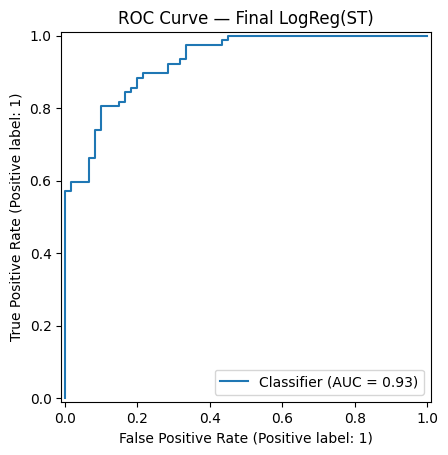

In [30]:
from sklearn.metrics import RocCurveDisplay

# If LogReg is best:
RocCurveDisplay.from_predictions(y_test, prob_logreg)
plt.title("ROC Curve — Final LogReg(ST)")
plt.show()
